# 10. Shared Modeling Framework Validation

This notebook validates the shared participant-level modeling framework developed for Week 4.

The objectives are to:

- load the participant-level datasets;
- validate the participant-level train, validation, and test split;
- verify the absence of participant leakage;
- inspect class distributions across all dataset partitions;
- prepare the modeling datasets;
- validate the shared preprocessing pipeline;
- verify feature selection and leakage prevention;
- validate the baseline classifiers;
- validate the shared modeling workflow.

This framework will be reused by the demographics-only,
questionnaire-only, and wearable-only modeling experiments.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

## 1. Import Modeling Framework

In [2]:
from src.modeling.data_loader import (
    load_all_datasets,
)

from src.modeling.split_validation import (
    validate_split,
)

from src.modeling.preprocessing import (
    prepare_dataset,
)

from src.modeling.baseline import (
    get_dummy_classifier,
)


from src.modeling.models import (
    get_logistic_regression,
    get_random_forest,
)

from src.modeling.outputs import (
    save_metrics,
    save_classification_report,
    save_confusion_matrix,
    save_confusion_matrix_figure,
    save_model_comparison,
    save_table,
    save_figure,
)

from src.modeling.workflow import (
    run_model,
    run_models,
)

## 2. Load Participant-Level Datasets

In [3]:
train_df, validation_df, test_df = load_all_datasets()

print(train_df.shape)
print(validation_df.shape)
print(test_df.shape)

(328, 2413)
(70, 2413)
(71, 2413)


The participant-level datasets were successfully loaded from the processed data folder. All three datasets share the same feature structure and are ready for model development.

## 3. Validate Participant-Level Split

Verify that the predefined train, validation, and test datasets
contain independent participant groups and satisfy the project
requirements.

In [4]:
validation_summary = validate_split(
    train_df,
    validation_df,
    test_df,
)

validation_summary

{'no_participant_overlap': True,
 'participant_counts': {'train': 328, 'validation': 70, 'test': 71},
 'train_class_distribution': label
 0     55
 1    193
 2     80
 Name: count, dtype: int64,
 'validation_class_distribution': label
 0    12
 1    41
 2    17
 Name: count, dtype: int64,
 'test_class_distribution': label
 0    12
 1    42
 2    17
 Name: count, dtype: int64}

## 4. Participant Summary

In [5]:
participant_summary = pd.DataFrame({

    "Dataset":[
        "Train",
        "Validation",
        "Test"
    ],

    "Participants":[
        validation_summary["participant_counts"]["train"],
        validation_summary["participant_counts"]["validation"],
        validation_summary["participant_counts"]["test"],
    ]

})

participant_summary

save_table(
    participant_summary,
    "participant_split_summary.csv",
)

The participant-level split contains all 469 participants without overlap between the training, validation, and testing datasets.

## 5. Class Distribution

In [6]:
class_distribution = pd.DataFrame({

    "Train":
        validation_summary["train_class_distribution"],

    "Validation":
        validation_summary["validation_class_distribution"],

    "Test":
        validation_summary["test_class_distribution"],

})

class_distribution

,Train,Validation,Test
label,,,
0,55,12,12
1,193,41,42
2,80,17,17


In [7]:
class_distribution_percent = (
    class_distribution.div(
        class_distribution.sum(axis=0),
        axis=1,
    )*100
).round(2)

class_distribution_percent

,Train,Validation,Test
label,,,
0,16.77,17.14,16.90
1,58.84,58.57,59.15
2,24.39,24.29,23.94


In [8]:
save_table(
    class_distribution,
    "class_distribution.csv",
)

save_table(
    class_distribution_percent,
    "class_distribution_percent.csv",
)

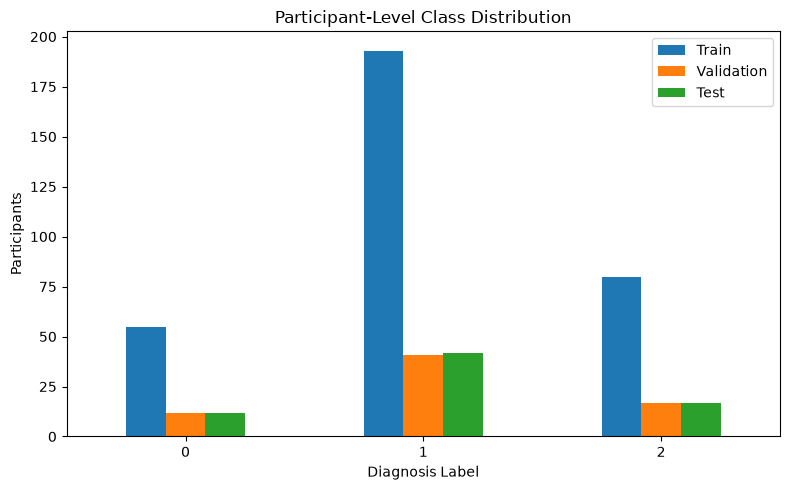

In [9]:
class_distribution.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Participant-Level Class Distribution")
plt.ylabel("Participants")
plt.xlabel("Diagnosis Label")
plt.xticks(rotation=0)

plt.tight_layout()
fig = plt.gcf()
save_figure(
    fig,
    "participant_class_distribution.png",
)
plt.show()

## 6. Prepare Modeling Dataset

In [10]:
X_train, y_train, preprocessing = prepare_dataset(
    train_df,
)

print(
    "Feature matrix:",
    X_train.shape,
)

print(
    "Target vector:",
    y_train.shape,
)

Feature matrix: (328, 2406)
Target vector: (328,)


## 7. Verify Leakage Prevention

In [11]:
excluded_columns = [
    "patient_id",
    "study_id",
    "duplicate_patient_id",
    "label",
    "condition_original",
    "condition_group",
    "questionnaire_name",
]

remaining_columns = [
    column
    for column in excluded_columns
    if column in X_train.columns
]

print(remaining_columns)

[]


Participant identifiers, diagnosis labels, and metadata were successfully removed before model training, preventing information leakage.

## 8. Feature Summary

In [12]:
feature_summary = pd.DataFrame({

    "Feature Type":[
        "Numerical",
        "Categorical"
    ],

    "Count":[
        X_train.select_dtypes(
            include="number"
        ).shape[1],

        X_train.select_dtypes(
            exclude="number"
        ).shape[1],
    ]

})

feature_summary

,Feature Type,Count
0,Numerical,2400
1,Categorical,6


## 9. Inspect Shared Preprocessing Pipeline

In [13]:
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

The preprocessing pipeline applies:

- median imputation to numerical variables;
- standardization of numerical variables;
- most-frequent imputation to categorical variables;
- one-hot encoding for categorical variables.

The same preprocessing pipeline will be reused across all baseline models.

## 10. Validate Dummy Classifier

In [14]:
dummy_results = run_model(

    model=get_dummy_classifier(),

    train_df=train_df,

    validation_df=validation_df,

)

dummy_results["metrics"]

{'accuracy': 0.5857142857142857,
 'balanced_accuracy': 0.3333333333333333,
 'macro_f1': 0.24624624624624625,
 'precision_macro': 0.19523809523809524,
 'recall_macro': 0.3333333333333333}

In [15]:
save_metrics(
    dummy_results["metrics"],
    "dummy_metrics.csv",
)

save_classification_report(
    dummy_results["classification_report"],
    "dummy_classification_report.csv",
)

save_confusion_matrix(
    dummy_results["confusion_matrix"],
    "dummy_confusion_matrix.csv",
)
save_confusion_matrix_figure(
    dummy_results["confusion_matrix"],
    "dummy_confusion_matrix.png",
)

## 11. Validate Logistic Regression

In [16]:
logistic_results = run_model(

    model=get_logistic_regression(),

    train_df=train_df,

    validation_df=validation_df,

)

logistic_results["metrics"]

{'accuracy': 0.7428571428571429,
 'balanced_accuracy': 0.6947234178224134,
 'macro_f1': 0.7068840579710146,
 'precision_macro': 0.7222222222222222,
 'recall_macro': 0.6947234178224134}

## 12. Validate Random Forest

In [17]:
random_forest_results = run_model(
    model=get_random_forest(),
    train_df=train_df,
    validation_df=validation_df,
)

random_forest_results["metrics"]

{'accuracy': 0.7285714285714285,
 'balanced_accuracy': 0.7373664913119719,
 'macro_f1': 0.7128476461809795,
 'precision_macro': 0.6961961961961962,
 'recall_macro': 0.7373664913119719}

In [18]:
save_metrics(
    random_forest_results["metrics"],
    "random_forest_metrics.csv",
)
save_classification_report(
    random_forest_results["classification_report"],
    "random_forest_classification_report.csv",
)
save_confusion_matrix(
    random_forest_results["confusion_matrix"],
    "random_forest_confusion_matrix.csv",
)
save_confusion_matrix_figure(
    random_forest_results["confusion_matrix"],
    "random_forest_confusion_matrix.png",
)

## 13. Compare Baseline Models

In [19]:
models = {
    "Dummy": get_dummy_classifier(),
    "Logistic Regression": get_logistic_regression(),
    "Random Forest": get_random_forest(),
}

results = run_models(
    models=models,
    train_df=train_df,
    validation_df=validation_df,
)

comparison = pd.DataFrame({
    name:result["metrics"]
    for name, result
    in results.items()
}).T

comparison

,accuracy,balanced_accuracy,macro_f1,precision_macro,recall_macro
Dummy,0.585714,0.333333,0.246246,0.195238,0.333333
Logistic Regression,0.742857,0.694723,0.706884,0.722222,0.694723
Random Forest,0.728571,0.737366,0.712848,0.696196,0.737366


In [20]:
save_model_comparison(
    comparison,
    "baseline_model_comparison.csv",
)

## 14. Logistic Regression Classification Report

In [21]:
results["Logistic Regression"][
    "classification_report"
]

,precision,recall,f1-score,support
0,0.727273,0.666667,0.695652,12.000000
1,0.772727,0.829268,0.800000,41.000000
2,0.666667,0.588235,0.625000,17.000000
accuracy,0.742857,0.742857,0.742857,0.742857
macro avg,0.722222,0.694723,0.706884,70.000000
weighted avg,0.739177,0.742857,0.739612,70.000000


## 15. Logistic Regression Confusion Matrix

In [22]:
results["Logistic Regression"][
    "confusion_matrix"
]

,Pred_Healthy,Pred_PD,Pred_Other
True_Healthy,8,3,1
True_PD,3,34,4
True_Other,0,7,10


In [23]:
save_metrics(
    logistic_results["metrics"],
    "logistic_metrics.csv",
)

save_classification_report(
    logistic_results["classification_report"],
    "logistic_classification_report.csv",
)

save_confusion_matrix(
    logistic_results["confusion_matrix"],
    "logistic_confusion_matrix.csv",
)
save_confusion_matrix_figure(
    logistic_results["confusion_matrix"],
    "logistic_confusion_matrix.png",
)